<a href="https://colab.research.google.com/github/Ali8089/Data_Science-and-ML/blob/ML_Algorithims/KNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install aaa-eda-analyzer

In [8]:
import pandas as pd
import numpy as np
from eda_analyzer import DataAnalyzer

In [9]:
df = pd.read_csv('/content/bank.csv',sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [10]:
analyzer = DataAnalyzer(data=df,target_col='y',download=False,export_pdf=False)

DATASET SUMMARY
Rows: 4521 | Columns: 17
Target Variable: y
Global Missingness: 0 / 76857 (0.0%)
Detected Types: {'datetime': 0, 'continuous': 3, 'categorical': 14, 'text': 0}

1. DATA QUALITY REPORT
Duplicate Rows: 0
Constant Columns: None
Columns >50% Missing: None
High Cardinality Categorical (>10 levels): ['age', 'job', 'day', 'month', 'campaign', 'previous']
Highly Skewed Continuous (|skew| > 1): [('balance', np.float64(6.6)), ('duration', np.float64(2.77)), ('pdays', np.float64(2.72))]
Quasi-Constant Columns (dominant value >= 95%): [('default', np.float64(98.32))]

2. OUTLIER DETECTION
  Column     Method  Outliers  Percentage
 balance IQR (1.5x)       506       11.19
duration IQR (1.5x)       330        7.30
   pdays IQR (1.5x)       816       18.05

3. BIVARIATE STATISTICAL TESTS (vs. Target)
  Feature                      Test   Metric  p-value  Assumptions_Met                                                                                                                     

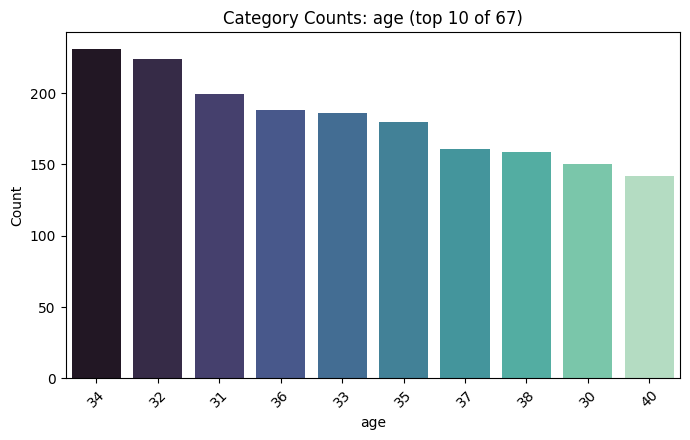

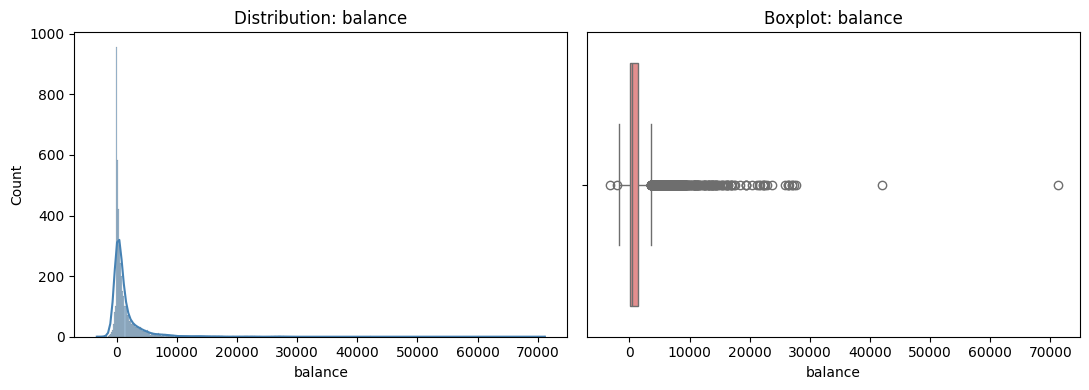

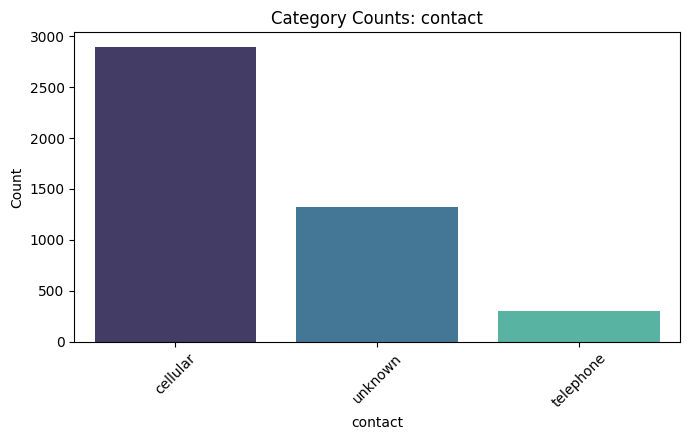

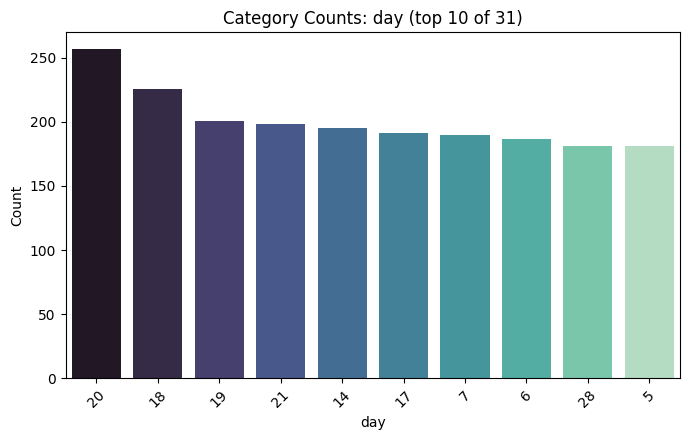

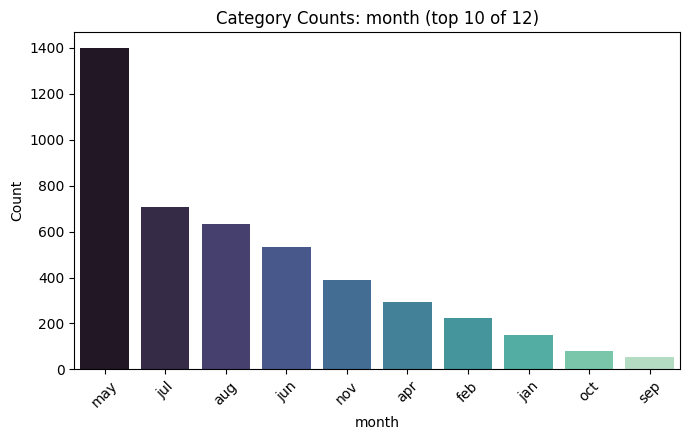

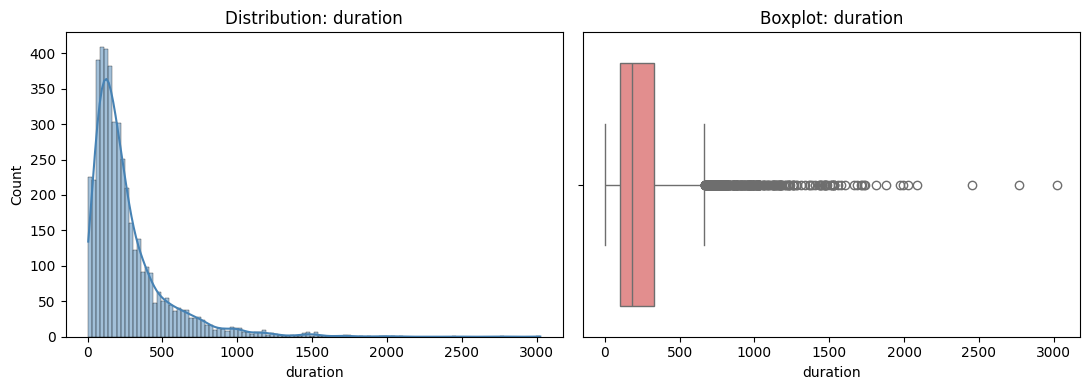

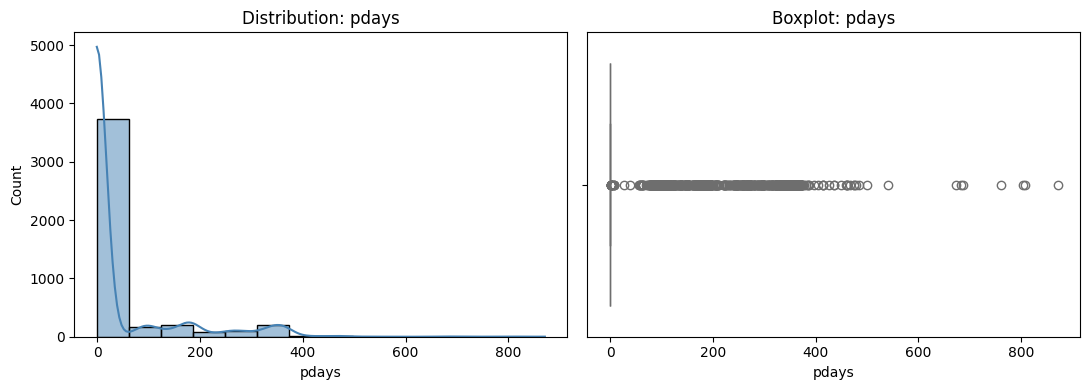

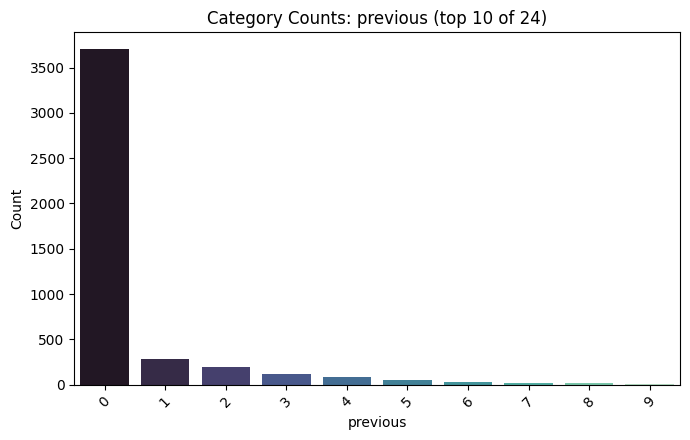

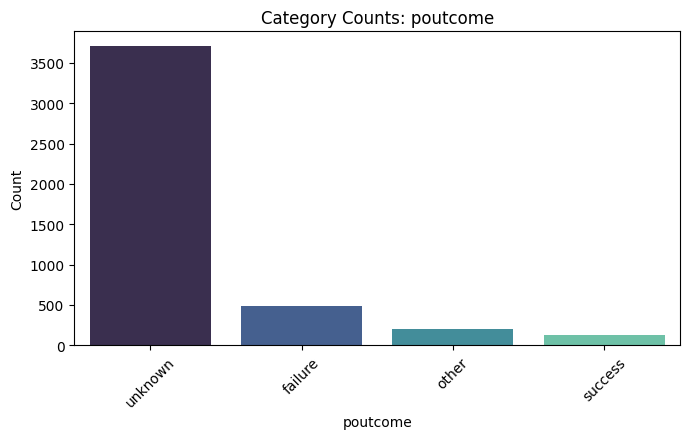

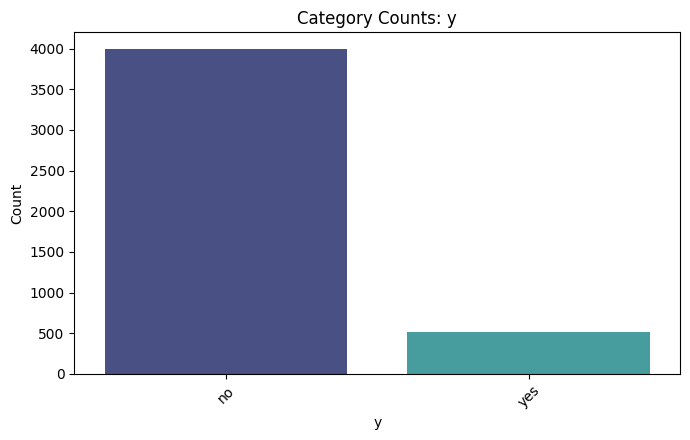

UNIVARIATE SUMMARY
  Feature        Type    N  Unique_Levels Top_Category  Top_Category_Pct  Plotted     Mean  Median      Std  Skew     Min     Max
      age categorical 4521           67.0           34              5.11     True      NaN     NaN      NaN   NaN     NaN     NaN
      job categorical 4521           12.0   management             21.43    False      NaN     NaN      NaN   NaN     NaN     NaN
  marital categorical 4521            3.0      married             61.87    False      NaN     NaN      NaN   NaN     NaN     NaN
education categorical 4521            4.0    secondary             51.01    False      NaN     NaN      NaN   NaN     NaN     NaN
  default categorical 4521            2.0           no             98.32    False      NaN     NaN      NaN   NaN     NaN     NaN
  balance  continuous 4521            NaN          NaN               NaN     True 1422.658   444.0 3009.638 6.596 -3313.0 71188.0
  housing categorical 4521            2.0          yes             56.6

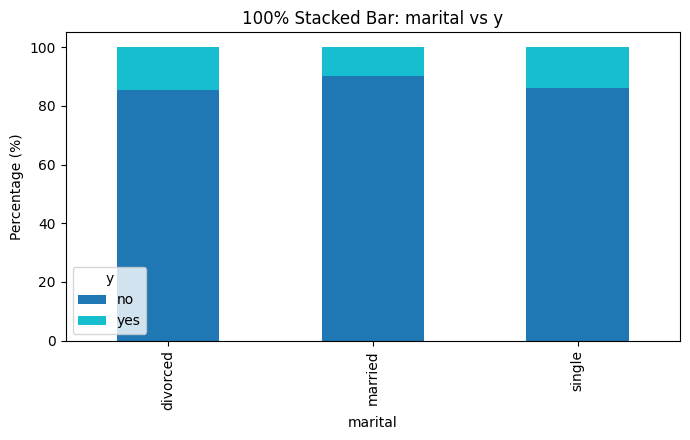

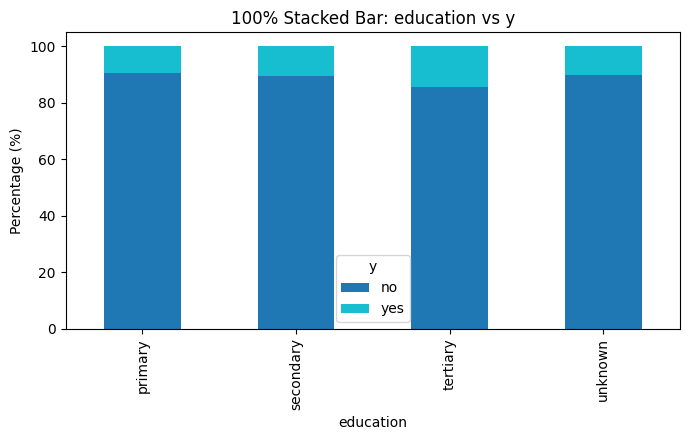

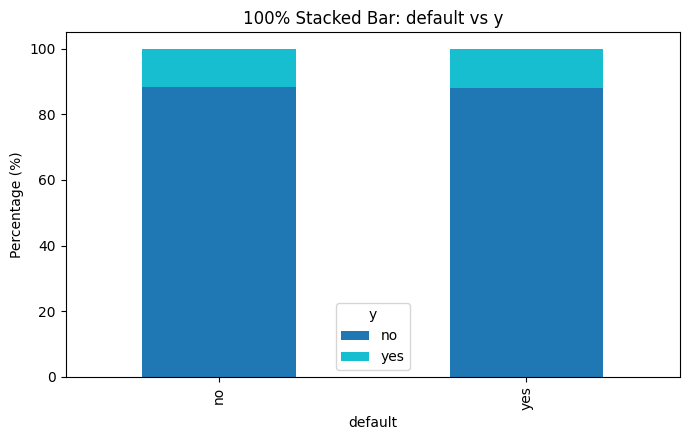

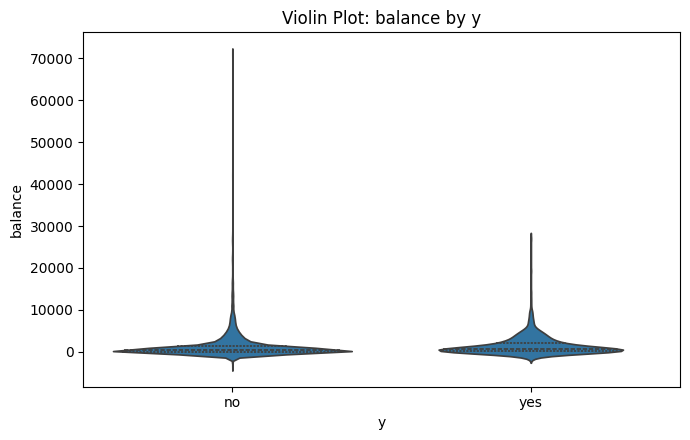

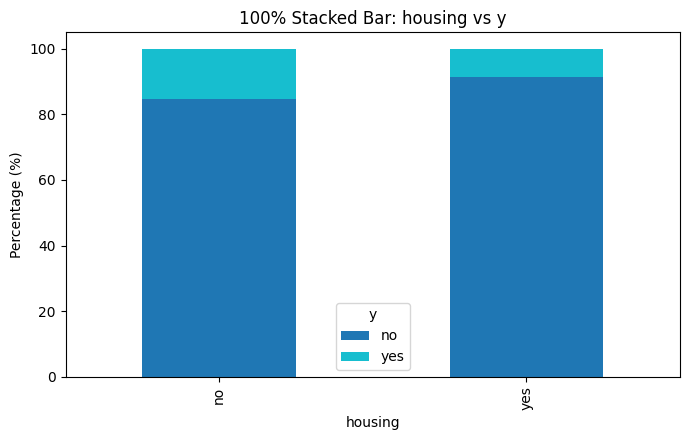

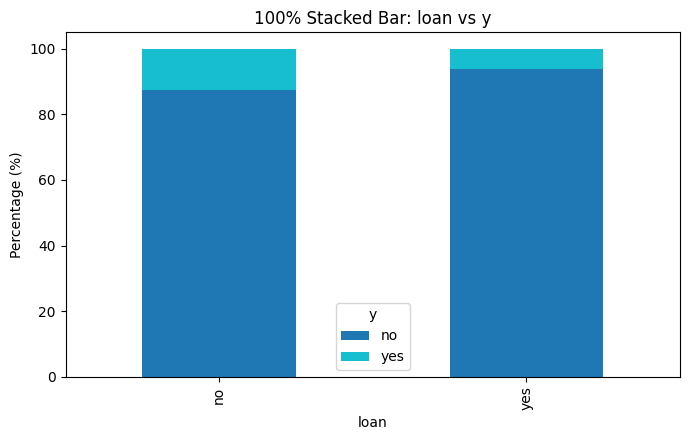

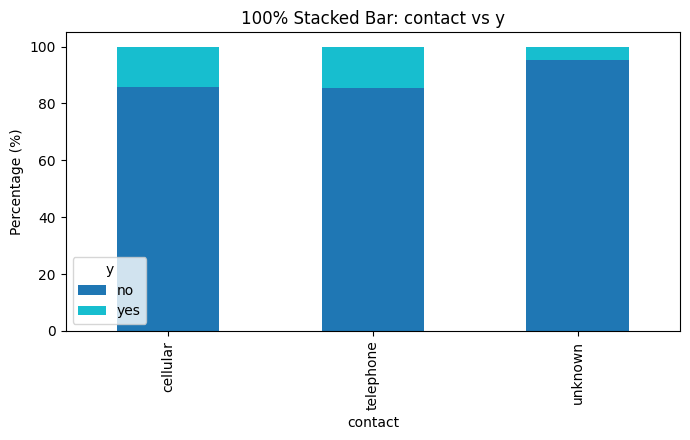

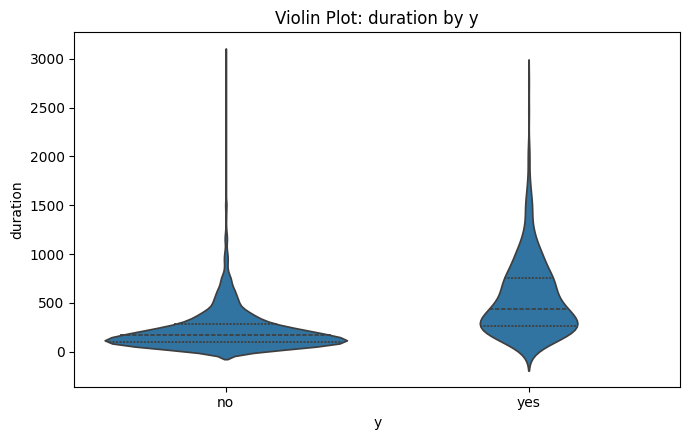

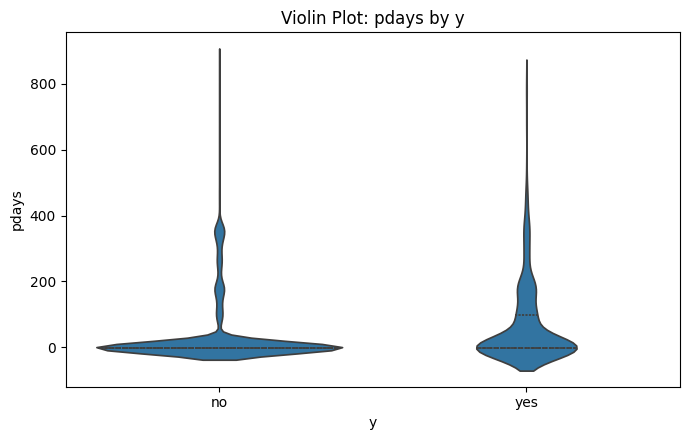

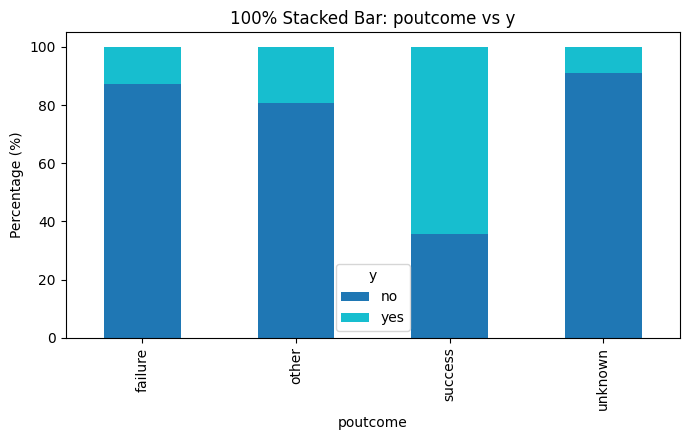

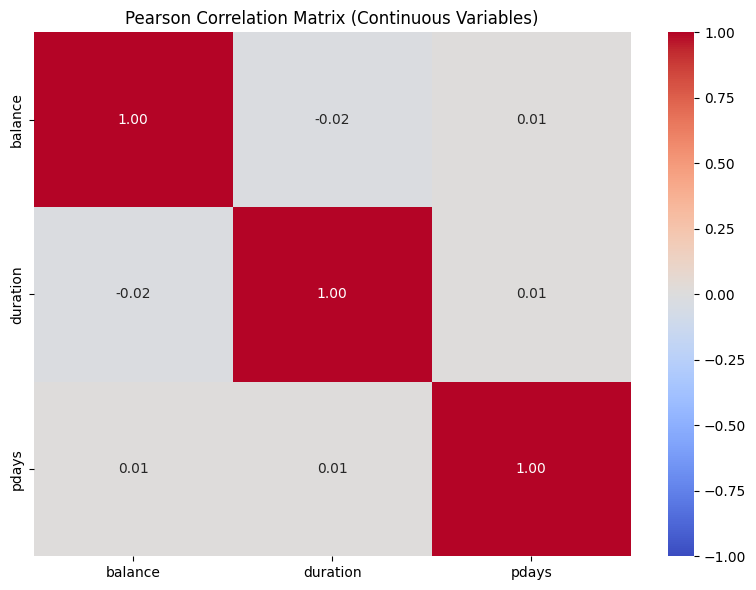

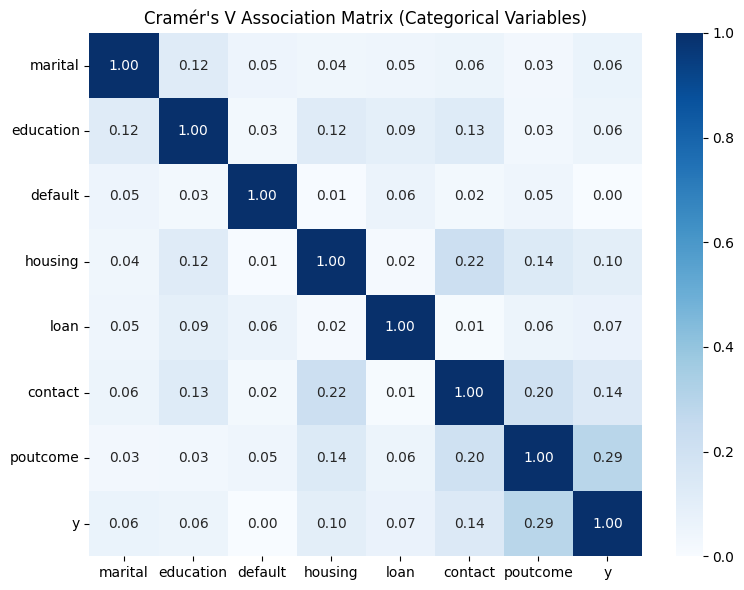

In [11]:
analyzer.run_all()

In [12]:
## Drop useless columns/feature selection(Only select top 10 columns)
df = df.drop(columns=['housing','campaign','loan','marital','education','default'])
df

,age,job,balance,contact,day,month,duration,pdays,previous,poutcome,y
0,30,unemployed,1787,cellular,19,oct,79,-1,0,unknown,no
1,33,services,4789,cellular,11,may,220,339,4,failure,no
2,35,management,1350,cellular,16,apr,185,330,1,failure,no
3,30,management,1476,unknown,3,jun,199,-1,0,unknown,no
4,59,blue-collar,0,unknown,5,may,226,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,-333,cellular,30,jul,329,-1,0,unknown,no
4517,57,self-employed,-3313,unknown,9,may,153,-1,0,unknown,no
4518,57,technician,295,cellular,19,aug,151,-1,0,unknown,no
4519,28,blue-collar,1137,cellular,6,feb,129,211,3,other,no


In [13]:
## Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['y'] = le.fit_transform(df['y'])

In [14]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['y'])
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(X,y,stratify=y,test_size=0.2,random_state=42)

In [15]:
cols = ['balance', 'duration', 'pdays']
bounds = {}
for col in cols:
    q1, q3 = X_train[col].quantile(0.25), X_train[col].quantile(0.75)
    iqr = q3 - q1
    bounds[col] = (q1 - 1.5*iqr, q3 + 1.5*iqr)

for col in cols:
    low, high = bounds[col]

    idx_drop_train = X_train[(X_train[col] > high) | (X_train[col] < low)].index
    X_train = X_train.drop(idx_drop_train)
    y_train = y_train.drop(idx_drop_train)

    idx_drop_test = X_test[(X_test[col] > high) | (X_test[col] < low)].index
    X_test = X_test.drop(idx_drop_test)
    y_test = y_test.drop(idx_drop_test)

In [16]:
## Feature Encondings
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore')

from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(exclude='object').columns


X_train_cat = pd.DataFrame(ohe.fit_transform(X_train[cat_cols]),columns=ohe.get_feature_names_out())
X_test_cat = pd.DataFrame(ohe.transform(X_test[cat_cols]),columns=ohe.get_feature_names_out())

X_train_num = pd.DataFrame(ss.fit_transform(X_train[num_cols]),columns=num_cols)
X_test_num = pd.DataFrame(ss.transform(X_test[num_cols]),columns=num_cols)

X_train = pd.concat([X_train_cat,X_train_num],axis=1)
X_test = pd.concat([X_test_cat,X_test_num],axis=1)



In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

accuracy = [None]*100
for n in range(1,101):
  knn = KNeighborsClassifier(n_neighbors= n)
  knn.fit(X_train,y_train)
  y_pred = knn.predict(X_test)
  accuracy[n-1]= accuracy_score(y_test,y_pred)
accuracy

[0.932258064516129,
 0.9403225806451613,
 0.9419354838709677,
 0.9419354838709677,
 0.9354838709677419,
 0.9387096774193548,
 0.9387096774193548,
 0.9403225806451613,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.9387096774193548,
 0.93870967741

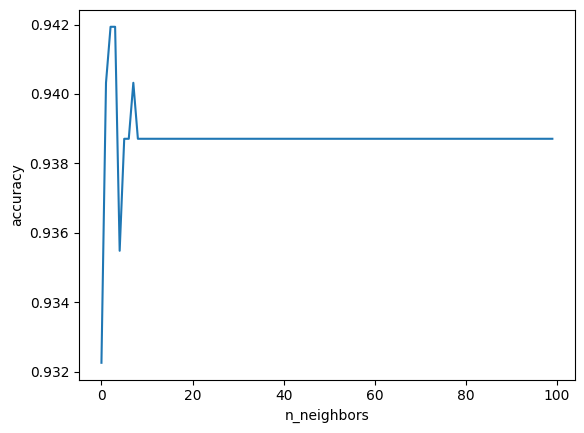

In [18]:
import matplotlib.pyplot as plt
plt.plot(range(100),accuracy)
plt.xlabel('n_neighbors')
plt.ylabel('accuracy')
plt.show()

In [19]:
accuracy.index(max(accuracy))
print(accuracy[accuracy.index(max(accuracy))])

0.9419354838709677
